# **CS 559-WS1: Machine Learning: Fundamentals and Applications**
# **Homework 2**

**Name: Ankit Dhandharia**

**CWID: 20033031**

In [24]:
# Import required libraries
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# **Question 1: Naive Bayes Classification**

## **Load dataset**

In [13]:
X, y = datasets.make_blobs(n_samples=400, n_features=5, centers=4, cluster_std=2, random_state=100)

## **Part a: Compute prior probability of each class**

In [14]:
unique_classes, class_counts = np.unique(y, return_counts=True)
p_Ck = class_counts / len(y)
print("Prior probabilities p(Ck):")
for k, prob in enumerate(p_Ck):
    print(f"Class {k}: {prob}")

Prior probabilities p(Ck):
Class 0: 0.25
Class 1: 0.25
Class 2: 0.25
Class 3: 0.25


## **Part b: Compute likelihood p(X|Ck)**

In [15]:
means = []
vars = []
for k in range(4):
    class_data = X[y == k]
    means.append(np.mean(class_data, axis=0))
    vars.append(np.var(class_data, axis=0))

p_X_given_Ck = np.zeros((len(X), 4))
for k in range(4):
    p_X_given_Ck[:, k] = np.prod(
        1/np.sqrt(2*np.pi*vars[k]) *
        np.exp(-0.5*((X - means[k])**2)/vars[k]),
        axis=1
    )

print("First few likelihood values p(X|Ck):")
print(p_X_given_Ck[:5])

First few likelihood values p(X|Ck):
[[4.35737431e-19 5.83470609e-36 1.65617426e-23 6.68636482e-05]
 [3.37890351e-18 3.74816408e-29 3.43372487e-07 1.15217600e-30]
 [1.51666045e-04 1.60401115e-28 6.93442926e-23 4.77305265e-19]
 [6.77565445e-16 4.96289533e-36 6.07868727e-18 1.26523237e-04]
 [2.41064492e-24 9.40159239e-50 1.02819772e-25 4.75405911e-06]]


## **Part c: Compute posterior probability p(Ck|X)**

In [16]:
p_Ck_given_X = p_X_given_Ck * p_Ck
p_Ck_given_X = p_Ck_given_X / np.sum(p_Ck_given_X, axis=1, keepdims=True)
predicted_class = np.argmax(p_Ck_given_X, axis=1)

print("First few posterior probabilities p(Ck|X):")
print(p_Ck_given_X[:5])
print("First few predicted classes:")
print(predicted_class[:5])

First few posterior probabilities p(Ck|X):
[[6.51680611e-15 8.72627540e-32 2.47694271e-19 1.00000000e+00]
 [9.84034434e-12 1.09157379e-22 1.00000000e+00 3.35546976e-24]
 [1.00000000e+00 1.05759411e-24 4.57216991e-19 3.14708059e-15]
 [5.35526487e-12 3.92251689e-32 4.80440386e-14 1.00000000e+00]
 [5.07070876e-19 1.97759266e-44 2.16277859e-20 1.00000000e+00]]
First few predicted classes:
[3 2 0 3 3]


## **Part d: Construct confusion matrix**


d. Confusion Matrix:
[[100   0   0   0]
 [  0 100   0   0]
 [  0   0 100   0]
 [  0   0   0 100]]


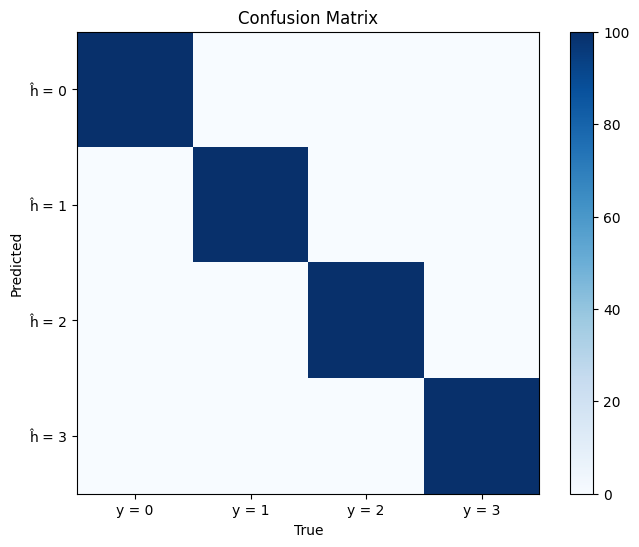

In [17]:
conf_matrix = confusion_matrix(y, predicted_class)
print("\nd. Confusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks(range(4), [f'y = {i}' for i in range(4)])
plt.yticks(range(4), [f'ĥ = {i}' for i in range(4)])
plt.xlabel('True')
plt.ylabel('Predicted')
plt.show()

## **Part e: Classify using sklearn's GaussianNB**

In [18]:
nb_model = GaussianNB()
nb_model.fit(X, y)
y_pred = nb_model.predict(X)
accuracy = np.mean(y_pred == y)
print("GaussianNB Accuracy: ",accuracy)

GaussianNB Accuracy:  1.0


# **Question 2: Perceptron**

## **Load data**

In [19]:
X, y = datasets.make_blobs(n_samples=400, n_features=5, centers=2, cluster_std=2, random_state=100)

## **Part a: Single iteration**

In [20]:
y = 2*y - 1

# Initializing w randomly
w = np.zeros(X.shape[1])

for i in range(len(y)):
    prediction = 1 if np.dot(w, X[i]) >= 0 else -1
    if prediction != y[i]:
        w = w + y[i] * X[i]

predictions_single = np.array([1 if np.dot(w, x) >= 0 else -1 for x in X])
accuracy_single = np.mean(predictions_single == y)
print("Perceptron accuracy (1 iteration): ",accuracy_single)
print("Weights after 1 iteration: ",w)

Perceptron accuracy (1 iteration):  1.0
Weights after 1 iteration:  [ -4.40243438   5.40070718   5.85134573 -11.83316766  13.69431902]


## **Part b: Multiple iterations**

In [22]:
iterations = [5, 10, 20, 50]
for num_iter in iterations:
    w = np.zeros(X.shape[1])
    for _ in range(num_iter):
        for i in range(len(y)):
            prediction = 1 if np.dot(w, X[i]) >= 0 else -1
            if prediction != y[i]:
                w = w + y[i] * X[i]

    predictions = np.array([1 if np.dot(w, x) >= 0 else -1 for x in X])
    accuracy = np.mean(predictions == y)
    print(f"\nAccuracy ({num_iter} iterations): {accuracy:.3f}")
    print(f"Final weights: {w}")


Accuracy (5 iterations): 1.000
Final weights: [ -4.40243438   5.40070718   5.85134573 -11.83316766  13.69431902]

Accuracy (10 iterations): 1.000
Final weights: [ -4.40243438   5.40070718   5.85134573 -11.83316766  13.69431902]

Accuracy (20 iterations): 1.000
Final weights: [ -4.40243438   5.40070718   5.85134573 -11.83316766  13.69431902]

Accuracy (50 iterations): 1.000
Final weights: [ -4.40243438   5.40070718   5.85134573 -11.83316766  13.69431902]


# **Question 3: Logistic Regression with Regularization**

## **Load dataset**

In [23]:
X, y = datasets.make_blobs(n_samples=400, n_features=5, centers=4, cluster_std=2, random_state=100)

## **Part a: Lasso regularization**

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


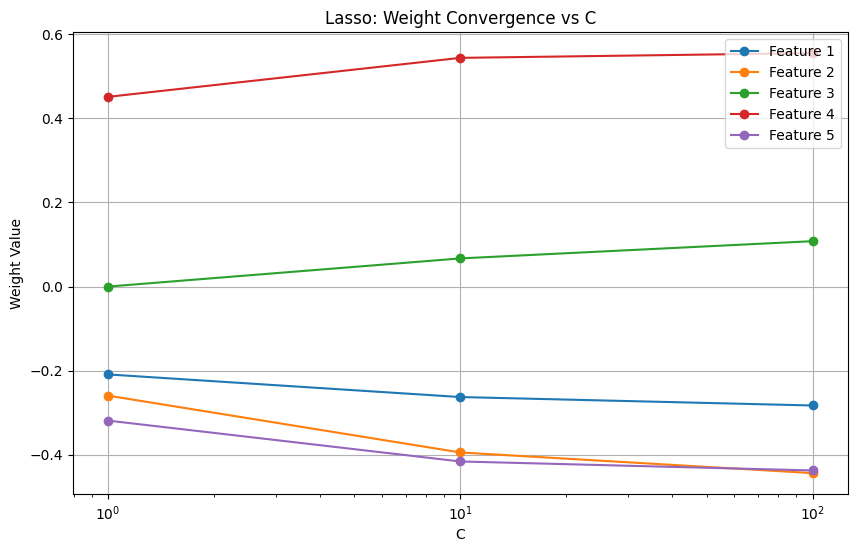

In [25]:
C_values = [100, 10, 1]
lasso_weights = []

for C in C_values:
    clf = LogisticRegression(penalty='l1', solver='saga', C=C)
    clf.fit(X, y)
    lasso_weights.append(clf.coef_)

# Plot weights convergence
plt.figure(figsize=(10, 6))
for i in range(5):
    feature_weights = [w[0][i] for w in lasso_weights]
    plt.plot(C_values, feature_weights, marker='o', label=f'Feature {i+1}')

plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Weight Value')
plt.title('Lasso: Weight Convergence vs C')
plt.legend()
plt.grid(True)
plt.show()

## **Part b: Feature importance analysis**

In [27]:
final_lasso = LogisticRegression(penalty='l1', solver='saga', C=1.0)
final_lasso.fit(X, y)
print("Lasso weights (C=1.0):")
print(final_lasso.coef_)

Lasso weights (C=1.0):
[[-0.21462818 -0.29377843  0.          0.46782922 -0.28788171]
 [-0.37927109  0.          0.32500132 -0.31087305  0.        ]
 [ 0.21673321 -0.24029856 -0.16944207 -0.39393734  0.        ]
 [ 0.37704847  0.60843313 -0.09102773  0.23693414  0.03770826]]


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## **Part c: Ridge regularization**

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


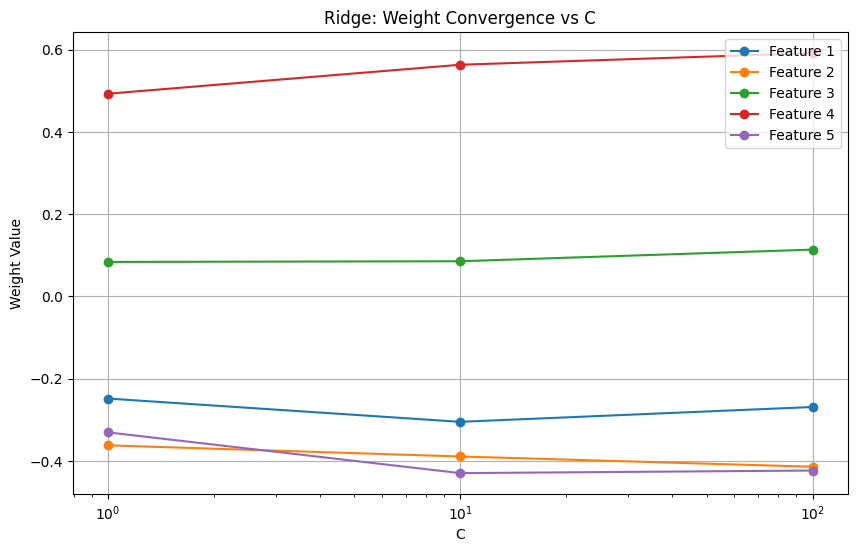

In [28]:
ridge_weights = []

for C in C_values:
    clf = LogisticRegression(penalty='l2', solver='saga', C=C)
    clf.fit(X, y)
    ridge_weights.append(clf.coef_)

plt.figure(figsize=(10, 6))
for i in range(5):
    feature_weights = [w[0][i] for w in ridge_weights]
    plt.plot(C_values, feature_weights, marker='o', label=f'Feature {i+1}')

plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Weight Value')
plt.title('Ridge: Weight Convergence vs C')
plt.legend()
plt.grid(True)
plt.show()